# CSE 2600 HW 4

In [17]:
import numpy as np
import pandas as pd
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt

## Q1

A.
\begin{gather*}
\bar{x} = \frac{65+70+68+73+75+80+85+78+90+100}{10} = 78.40\\\\
s = \sqrt{\frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}} = \frac{179.56+70.56+108.16+29.16+11.56+2.56+43.56+0.16+134.56+466.56}{9}\\
s^2 = \frac{1046.40}{9} = 116.266\\
s = \sqrt{116.266} = 10.7827\\
r = t*(\frac{s}{\sqrt{n}}); t = 2.262, n = 10, s = 10.7827\\
r = 2.262*(\frac{10.7827}{\sqrt{10}}) = 7.7129\\
[\bar{x} - r, \bar{x} +r] = [78.40−7.71, 78.40+7.71] = [70.69, 86.11]
\end{gather*}

So the 95% confidence interval is approximately (70.69, 86.11).

In [53]:
data = np.array([65, 70, 68, 73, 75, 80, 85, 78, 90, 100])
n = len(data)

#Part B: 40 bootstrapped samples of the data, calculate the mean and estimate the 95% confidence interval 
B = 40
means = [np.mean(np.random.choice(data, size=n, replace=True)) for _ in range(B)]

lower = np.percentile(means, 2.5)
upper = np.percentile(means, 97.5)

print("Bootstrap Sample Means:")
print(np.round(means, 2))
print(f"\n95% Confidence Interval for Population Mean: ({lower:.2f}, {upper:.2f})")

Bootstrap Sample Means:
[73.6 78.4 78.4 76.8 80.1 81.8 79.3 79.6 78.2 80.5 75.6 78.7 81.2 74.8
 73.4 74.4 73.1 86.  77.3 81.9 77.8 75.6 77.9 78.2 74.3 76.5 79.9 80.6
 79.6 81.5 73.2 83.7 79.1 76.4 77.6 76.5 75.1 73.7 76.6 73.9]

95% Confidence Interval for Population Mean: (73.20, 83.76)


C. For this specific case with n = 10 and data that look reasonably normal, the t-distribution method is more reliable. It’s built for small samples and provides a stable confidence interval with less sensitivity to random resampling noise. The bootstrap method is still useful, but it becomes more dependable with larger samples or when the population distribution is clearly non-normal.

## Q2

In [54]:
#Part A: 5 subsets, each containing only two score
np.random.shuffle(data)
folds = np.array_split(data, 5)
print("\nA. 5 Folds after Shuffling:")
for i, fold in enumerate(folds, 1):
    print(f"Fold {i}: {fold}")

#Part B: Calculate the average score
training_means = []
print("\nB. Training Means for Each Fold:")
for i in range(5):
    validation = folds[i]
    training = np.concatenate([folds[j] for j in range(5) if j != i])
    mean_train = np.mean(training)
    training_means.append(mean_train)
    print(f"Fold {i+1}: Validation = {validation}, Training Mean = {mean_train:.2f}")

print("\nTraining means for all 5 folds:", np.round(training_means, 2))

#Part C: Overall average of the training means
mae_list = []
print("\nC. Mean Absolute Errors for Each Fold:")
for i in range(5):
    prediction = training_means[i]
    mae = np.mean(np.abs(validation - prediction))
    mae_list.append(mae)
    print(f"Fold {i+1}: MAE = {mae:.2f}")

#Part D: Average mean absolute error
average_mae = np.mean(mae_list)
print(f"\nD. Average MAE across all 5 folds = {average_mae:.2f}")

#Part E: Mean absolute error of the “new” set
overall_mean = np.mean(data)
print(f"Overall mean = {overall_mean:.2f}")

mae_new_set = np.mean(np.abs(data - overall_mean))
print(f"\nE. MAE on new exam scores = {mae_new_set:.2f}")



A. 5 Folds after Shuffling:
Fold 1: [78 73]
Fold 2: [80 85]
Fold 3: [100  68]
Fold 4: [65 90]
Fold 5: [75 70]

B. Training Means for Each Fold:
Fold 1: Validation = [78 73], Training Mean = 79.12
Fold 2: Validation = [80 85], Training Mean = 77.38
Fold 3: Validation = [100  68], Training Mean = 77.00
Fold 4: Validation = [65 90], Training Mean = 78.62
Fold 5: Validation = [75 70], Training Mean = 79.88

Training means for all 5 folds: [79.12 77.38 77.   78.62 79.88]

C. Mean Absolute Errors for Each Fold:
Fold 1: MAE = 6.62
Fold 2: MAE = 4.88
Fold 3: MAE = 4.50
Fold 4: MAE = 6.12
Fold 5: MAE = 7.38

D. Average MAE across all 5 folds = 5.90
Overall mean = 78.40

E. MAE on new exam scores = 8.28


## Q3

A. Training and Test Set Sizes
Training set size: (800, 18)
Test set size: (270, 18)

 B. Confusion Matrix (Training Data):
[[451  43]
 [ 82 224]]
Total Misclassification Error (Training Data): 0.156


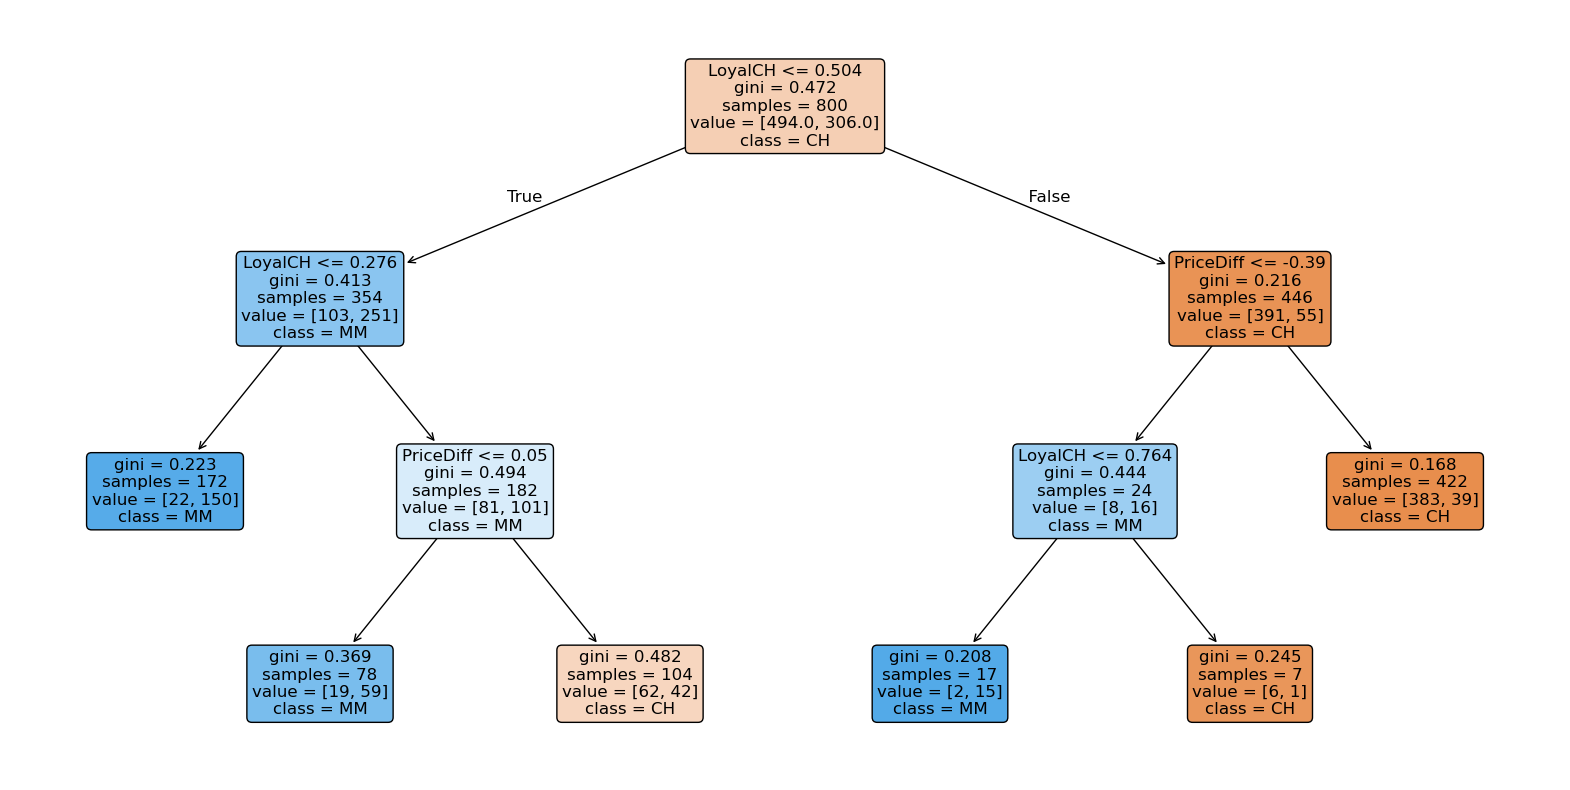

In [6]:
OJ = load_data('OJ')

#Part A: Create a training set 
OJ['Store7'] = OJ['Store7'].map({'Yes': 1, 'No': 0})
train_data, test_data = train_test_split(OJ, train_size=800, random_state=42, shuffle=True)

X_train = train_data.drop(columns=['Purchase'])
y_train = train_data['Purchase']

X_test = test_data.drop(columns=['Purchase'])
y_test = test_data['Purchase']

print("A. Training and Test Set Sizes")
print(f"Training set size: {train_data.shape}")
print(f"Test set size: {test_data.shape}")

#Part B: Fit a single tree to the training data
tree = DecisionTreeClassifier(max_leaf_nodes=6, random_state=42)
tree.fit(X_train, y_train)

y_train_pred = tree.predict(X_train)

cm = confusion_matrix(y_train, y_train_pred)
print("\n B. Confusion Matrix (Training Data):")
print(cm)

misclass_error = 1 - accuracy_score(y_train, y_train_pred)
print(f"Total Misclassification Error (Training Data): {misclass_error:.3f}")

#Part C: Plot the tree
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X_train.columns, class_names=tree.classes_,
          filled=True, rounded=True, fontsize=12)
plt.show()

**Cont. C.** 
The classification tree shows that **customer loyalty to Citrus Hill (`LoyalCH`) is the most important predictor** of purchase behavior. At the root, the tree splits on `LoyalCH <= 0.504`. For customers with low loyalty (`LoyalCH <= 0.276`), **price differences (`PriceDiff`) begin to influence their purchase decisions**, but the higher Gini values in these leaves indicate some uncertainty. On the other hand, for customers where `PriceDiff <= -0.389`, further splits on `LoyalCH <= 0.764` produce leaves with lower Gini values, reflecting more confident predictions. Overall, the tree suggests that **loyalty drives the first division in purchase behavior**, and **price differences play a secondary role**, especially when loyalty is moderate or low. Lower Gini values at the leaves indicate more similar groups where the model is more certain about the likely purchase choice.

In [8]:
#Part D: Predict the response on the test data
y_test_pred = tree.predict(X_test)

cm_test = confusion_matrix(y_test, y_test_pred)
print("D. Confusion Matrix (Test Data):")
print(cm_test)

misclass_error_test = 1 - accuracy_score(y_test, y_test_pred)
print(f"Total Misclassification Error (Test Data): {misclass_error_test:.3f}")

#Part E: Fit a new tree to the data, with 8 for the maximum number of leaf nodes
tree2 = DecisionTreeClassifier(max_leaf_nodes=8, random_state=42)
tree2.fit(X_train, y_train)

y_test_pred2 = tree2.predict(X_test)

test_error = 1 - accuracy_score(y_test, y_test_pred2)
print("\nE. Decision Tree with 8 Leaves:")
print(f"Test Misclassification Error (8 leaves): {test_error:.4f}")

error_change = test_error - test_error
print(f"Change in Test Error from 6 to 8 leaves: {error_change:.4f}") 

D. Confusion Matrix (Test Data):
[[149  10]
 [ 42  69]]
Total Misclassification Error (Test Data): 0.193

E. Decision Tree with 8 Leaves:
Test Misclassification Error (8 leaves): 0.2148
Change in Test Error from 6 to 8 leaves: 0.0000


**F.** 
The classification tree with 8 leaf nodes in part (e) shows signs of overfitting. While increasing the number of leaf nodes allows the tree to better capture patterns in the training data, the test misclassification error actually increased from 0.193 (with 6 leaf nodes) to 0.215. This indicates that the extra complexity caused the model to fit noise in the training set rather than meaningful patterns, reducing its ability to generalize to new data. The simpler tree with 6 leaf nodes had slightly higher training error but lower test error, showing better balance between bias and variance. Overall, the increase in test error with the more complex tree confirms that it is overfit.

G. Cross-Validation Errors for Different Leaf Nodes:
   Optimal number of leaf nodes = 8
   Test misclassification error with optimal leaf nodes: 0.215
Cross-validation showed that 8 leaf nodes is the best.
Using 8 leaves didn’t really lower the test error, so the tree was already doing about as well as it could.

 H. Initial Hyperparameters:
  n_estimators: 100
  max_features: sqrt
  max_depth: None
Initial Test Misclassification Rate: 0.2407

 I.Final Random Forest Hyperparameters:
  max_depth: 10
  max_features: sqrt
  min_samples_split: 10
  n_estimators: 100
Test Misclassification Rate: 0.2037


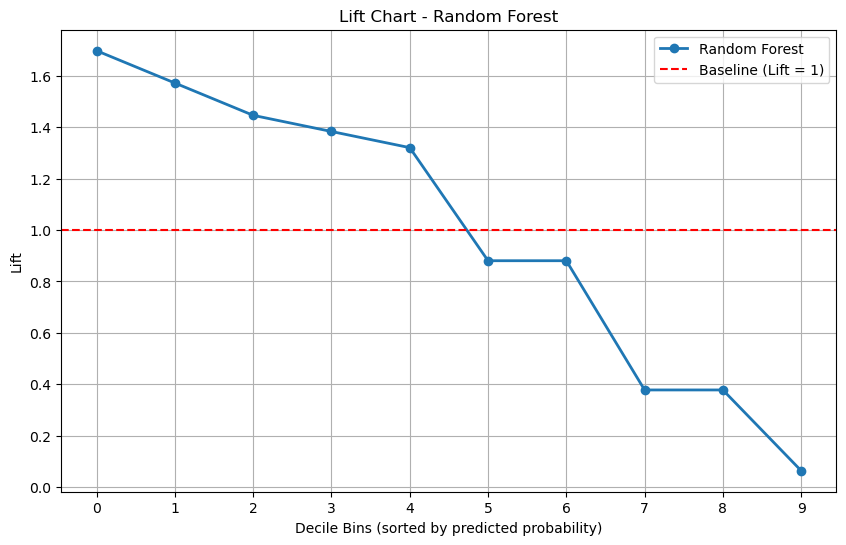

Segmentation for Random Forest:
  Top 10%: Lift = 1.70x
  Top 20%: Lift = 1.57x
  Top 30%: Lift = 1.45x

K. Gradient Boosting Initial Hyperparameters:
  n_estimators: 100
  learning_rate: 0.1
  max_depth: 3
Total Misclassification Rate on Test Set: 0.2148

 L. Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}
Misclassification Rate: 0.1926


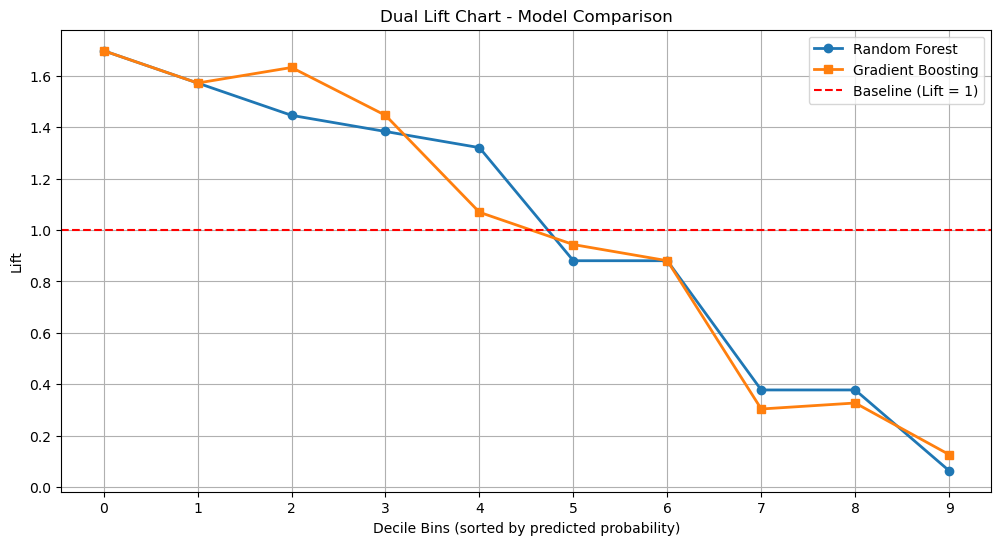

In [62]:
#Part G: Cross-validation to determine the optimal number of leaf nodes
leaf_nodes = range(2, 21)  
cv_errors = []

for max_leaf in leaf_nodes:
    tree_cv = DecisionTreeClassifier(max_leaf_nodes=max_leaf, random_state=42)
    scores = cross_val_score(tree_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_errors.append(1 - np.mean(scores))

print ("G. Cross-Validation Errors for Different Leaf Nodes:")
optimal_leaf_nodes = leaf_nodes[np.argmin(cv_errors)]
print(f"   Optimal number of leaf nodes = {optimal_leaf_nodes}")

tree_opt = DecisionTreeClassifier(max_leaf_nodes=optimal_leaf_nodes, random_state=42)
tree_opt.fit(X_train, y_train)

y_test_pred_opt = tree_opt.predict(X_test)

misclass_error_opt = 1 - accuracy_score(y_test, y_test_pred_opt)
print(f"   Test misclassification error with optimal leaf nodes: {misclass_error_opt:.3f}")
print("Cross-validation showed that 8 leaf nodes is the best.")
print("Using 8 leaves didn’t really lower the test error, so the tree was already doing about as well as it could.")

#Part H: Create a random forest model to predict Purchase
rf_initial = RandomForestClassifier(
    n_estimators=100,   
    max_features='sqrt',   
    max_depth=None,        
    bootstrap=True,        
    random_state=42        
)

rf_initial.fit(X_train, y_train)

print("\n H. Initial Hyperparameters:")
print(f"  n_estimators: {rf_initial.n_estimators}")
print(f"  max_features: {rf_initial.max_features}")
print(f"  max_depth: {rf_initial.max_depth}")

y_test_pred_rf_initial = rf_initial.predict(X_test)

test_error_rf_initial = 1 - accuracy_score(y_test, y_test_pred_rf_initial)
print(f"Initial Test Misclassification Rate: {test_error_rf_initial:.4f}")

#Part I: terate on your random forest model to search for optimal hyperparameters.
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("\n I.Final Random Forest Hyperparameters:")
for param, value in grid_search_rf.best_params_.items():
    print(f"  {param}: {value}")

rf_best = grid_search_rf.best_estimator_
y_test_pred = rf_best.predict(X_test)

misclass_rate = 1 - accuracy_score(y_test, y_test_pred)
print(f"Test Misclassification Rate: {misclass_rate:.4f}")

#Part J: Construct a lift chart for your final random forest model on test data.
def plot_lift_chart(y_true, y_probs, model_name='Random Forest', positive_class='CH', n_bins=10):
    y_true_binary = (y_true == positive_class).astype(int)
    
    data = pd.DataFrame({'y_true': y_true_binary, 'y_probs': y_probs})
    data = data.sort_values(by='y_probs', ascending=False)  
    
    data['bin'] = pd.qcut(data['y_probs'], n_bins, labels=False)
    
    # Calculate lift statistics
    lift_data = data.groupby('bin').agg(
        total_count=('y_true', 'count'),
        actual_positive=('y_true', 'sum'),
        predicted_mean=('y_probs', 'mean')
    ).reset_index()
    
    overall_response_rate = data['y_true'].mean()
    lift_data['response_rate'] = lift_data['actual_positive'] / lift_data['total_count']
    lift_data['lift'] = lift_data['response_rate'] / overall_response_rate
    
    plt.figure(figsize=(10, 6))
    plt.plot(lift_data['bin'], lift_data['lift'], marker='o', linewidth=2, label=model_name)
    plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Lift = 1)')
    plt.title(f'Lift Chart - {model_name}')
    plt.xlabel('Decile Bins (sorted by predicted probability)')
    plt.ylabel('Lift')
    plt.xticks(lift_data['bin'])
    plt.legend()
    plt.grid()
    plt.show()
    
    print(f"Segmentation for {model_name}:")
    for i in range(min(3, n_bins)):
        print(f"  Top {(i+1)*10}%: Lift = {lift_data.iloc[i]['lift']:.2f}x")

plot_lift_chart(y_test, y_probs_rf, model_name='Random Forest')

# Part K: Create a gradient boosting model to predict Purchase.
gbm = GradientBoostingClassifier(
    n_estimators=100,     
    learning_rate=0.1,    
    max_depth=3,          
    random_state=42
)

gbm.fit(X_train, y_train)

y_test_pred_gbm = gbm.predict(X_test)

print("\nK. Gradient Boosting Initial Hyperparameters:")
print(f"  n_estimators: {gbm.n_estimators}")
print(f"  learning_rate: {gbm.learning_rate}")
print(f"  max_depth: {gbm.max_depth}")

misclass_error_gbm = 1 - accuracy_score(y_test, y_test_pred_gbm)
print(f"Total Misclassification Rate on Test Set: {misclass_error_gbm:.4f}")

# Part L: Iterate on gradient boosting model for optimal hyperparameters
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'subsample': [0.8, 1.0]
}

gb = GradientBoostingClassifier(random_state=42)
gb_grid_search = GridSearchCV(gb, gb_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gb_grid_search.fit(X_train, y_train)

print(f"\n L. Best Hyperparameters: {gb_grid_search.best_params_}")
gb_final = gb_grid_search.best_estimator_
y_test_pred_gb_final = gb_final.predict(X_test)
test_error_gb_final = 1 - accuracy_score(y_test, y_test_pred_gb_final)
print(f"Misclassification Rate: {test_error_gb_final:.4f}")

# Part M: Dual Lift Chart Comparison
def plot_double_lift_chart(y_true, y_prob1, y_prob2, 
                          model1_name='Random Forest', model2_name='Gradient Boosting',
                          positive_class='CH', n_bins=10):

    y_true_binary = (y_true == positive_class).astype(int)
    
    data1 = pd.DataFrame({'y_true': y_true_binary, 'y_probs': y_prob1})
    data1 = data1.sort_values(by='y_probs', ascending=False)
    data1['bin'] = pd.qcut(data1['y_probs'], n_bins, labels=False)
    
    data2 = pd.DataFrame({'y_true': y_true_binary, 'y_probs': y_prob2})
    data2 = data2.sort_values(by='y_probs', ascending=False)  
    data2['bin'] = pd.qcut(data2['y_probs'], n_bins, labels=False)
    
    lift_data1 = data1.groupby('bin').agg(
        actual_positive=('y_true', 'sum'),
        total_count=('y_true', 'count')
    ).reset_index()
    
    lift_data2 = data2.groupby('bin').agg(
        actual_positive=('y_true', 'sum'), 
        total_count=('y_true', 'count')
    ).reset_index()
    
    overall_response_rate = y_true_binary.mean()
    lift_data1['lift'] = (lift_data1['actual_positive'] / lift_data1['total_count']) / overall_response_rate
    lift_data2['lift'] = (lift_data2['actual_positive'] / lift_data2['total_count']) / overall_response_rate
    
    plt.figure(figsize=(12, 6))
    plt.plot(lift_data1['bin'], lift_data1['lift'], marker='o', linewidth=2, 
             label=model1_name, markersize=6)
    plt.plot(lift_data2['bin'], lift_data2['lift'], marker='s', linewidth=2, 
             label=model2_name, markersize=6)
    plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Lift = 1)')
    plt.title('Dual Lift Chart - Model Comparison')
    plt.xlabel('Decile Bins (sorted by predicted probability)')
    plt.ylabel('Lift')
    plt.xticks(lift_data1['bin'])
    plt.legend()
    plt.grid()
    plt.show()

y_prob_rf = rf_best.predict_proba(X_test)[:, 1]  
y_prob_gb = gb_final.predict_proba(X_test)[:, 1]  

plot_double_lift_chart(y_test, y_prob_rf, y_prob_gb)

**Cont. M.** 
This dual lift chart compares the performance of the Random Forest (blue line) and Gradient Boosting (green line) models on the test data. Both models show similar lift curves, indicating that they capture positive responses at almost the same rate across the sample. Neither model significantly outperforms the other, as their lines overlap closely. However, the **Gradient Boosting** model better segments the data than the Random Forest model. Its higher lift in the early deciles and more consistent performance across bins show stronger predictive ranking ability. Overall, both models segment the data effectively but the Gradient Boosting seems more effective for targeted predictions.